In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm
import matplotlib.dates as mdates
import requests
import time
from datetime import datetime, timezone
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tsa.api import VAR
from scipy.stats import invgamma, invwishart
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
TRADITIONAL_DATA_PATH = "data/traditional_market_data.xlsx"
CRYPTO_DATA_PATH = "data/crypto_ohlcv_data.xlsx"

df_traditional = pd.read_excel(TRADITIONAL_DATA_PATH)
df_crypto = pd.read_excel(CRYPTO_DATA_PATH)


In [3]:
df_traditional

,Dates,Open _DXY,Last _DXY,High _DXY,Low _DXY,Open _XAU,Last _XAU,High _XAU,Low _XAU,Open _VIX,...,Open _SP,Last _SP,Volume_SP,High _SP,Low _SP,Open _KBW,Last _KBW,Volume_KBW,High _KBW,Low _KBW
0,2020-01-01,96.500,96.445,97.103,96.418,1517.27,1517.29,1518.20,1517.25,14.84,...,3215.18,3230.78,431595893,3231.72,3212.03,112.96,113.36,35058140,113.40,112.84
1,2020-01-02,96.475,96.846,96.873,96.425,1519.15,1529.13,1531.40,1517.29,13.46,...,3244.67,3257.85,517131498,3258.14,3235.53,113.77,114.12,37700124,114.13,112.99
2,2020-01-03,96.789,96.838,97.105,96.710,1529.13,1552.20,1553.52,1528.07,15.01,...,3226.36,3234.85,509241848,3246.15,3222.34,112.99,112.48,41224273,113.03,111.76
3,2020-01-06,96.847,96.671,96.897,96.540,1560.84,1565.74,1588.13,1560.64,15.45,...,3217.55,3246.28,575576705,3246.84,3214.64,111.58,111.87,44118485,111.88,111.04
4,2020-01-07,96.658,97.005,97.091,96.621,1565.74,1574.37,1577.41,1555.34,13.84,...,3241.86,3237.18,499721948,3244.91,3232.43,111.52,111.11,32033619,111.75,110.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1598,2026-02-16,96.875,96.915,97.120,96.875,5036.99,4992.08,5037.61,4966.41,20.73,...,6834.27,6836.17,948565671,6881.96,6794.55,164.87,166.39,53152724,167.00,162.79
1599,2026-02-17,97.123,97.155,97.546,97.072,4993.85,4877.89,5000.65,4843.51,21.74,...,6819.86,6843.22,932380409,6866.99,6775.50,167.24,167.44,58780779,169.27,166.85
1600,2026-02-18,97.135,97.703,97.742,97.118,4871.29,4977.56,5010.90,4854.27,19.78,...,6855.48,6881.31,875476217,6909.12,6849.66,167.85,169.67,53391650,170.74,167.71
1601,2026-02-19,97.728,97.925,98.074,97.572,4980.47,4996.10,5022.25,4960.83,19.34,...,6861.34,6861.89,760757761,6879.12,6833.06,168.49,167.62,47711951,168.63,166.04


In [4]:
df_crypto

,Date,BTC_USD_Open,BTC_USD_High,BTC_USD_Low,BTC_USD_Close,BTC_USD_Volume,ETH_USD_Open,ETH_USD_High,ETH_USD_Low,ETH_USD_Close,...,USDC_USD_Open,USDC_USD_High,USDC_USD_Low,USDC_USD_Close,USDC_USD_Volume,USDT_USD_Open,USDT_USD_High,USDT_USD_Low,USDT_USD_Close,USDT_USD_Volume
0,2020-01-01,7157.89,7230.20,7152.40,7179.62,82.117836,128.64,132.67,128.21,130.33,...,0.9962,0.9978,0.9960,0.9970,2.704184e+05,0.9962,0.9982,0.9957,0.9972,41263.06
1,2020-01-02,7172.85,7186.39,6906.33,6946.64,134.846719,130.00,130.00,126.06,126.90,...,0.9970,0.9979,0.9952,0.9970,9.749009e+05,0.9971,0.9980,0.9952,0.9971,80163.08
2,2020-01-03,6946.49,7400.00,6855.51,7322.74,200.076483,127.01,134.93,125.43,133.71,...,0.9970,0.9995,0.9960,0.9984,1.989928e+06,0.9971,0.9998,0.9967,0.9984,111677.79
3,2020-01-04,7336.14,7392.88,7262.64,7349.45,97.315281,134.39,135.23,132.46,133.87,...,0.9984,0.9994,0.9976,0.9979,7.414087e+05,0.9988,1.0005,0.9976,0.9990,175676.46
4,2020-01-05,7349.15,7488.93,7321.77,7353.97,187.059656,134.64,137.95,134.24,135.26,...,0.9983,0.9998,0.9980,0.9991,8.063169e+05,0.9984,1.0002,0.9980,0.9987,204521.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2238,2026-02-16,68700.82,69986.96,67241.71,68842.50,5.699150,1963.10,2020.83,1940.00,1997.05,...,0.9989,0.9990,0.9988,0.9990,1.204200e+04,0.9983,0.9990,0.9981,0.9989,665732.00
2239,2026-02-17,68828.75,69103.33,66564.32,67441.47,10.543430,1995.16,2010.67,1941.05,1989.89,...,0.9989,0.9990,0.9988,0.9990,1.690000e+04,0.9989,0.9990,0.9983,0.9986,943791.00
2240,2026-02-18,67419.98,68388.68,65870.00,66414.00,15.230950,1992.04,2034.69,1923.54,1952.28,...,0.9989,1.0000,0.9971,1.0000,1.630820e+05,0.9985,0.9995,0.9984,0.9991,875213.00
2241,2026-02-19,66396.60,67246.54,65626.55,66944.69,17.531010,1953.77,1985.80,1906.89,1948.00,...,0.9994,1.0039,0.9994,0.9998,1.030440e+05,0.9995,0.9998,0.9990,0.9995,727926.00


In [5]:
df_crypto['Date'] = pd.to_datetime(df_crypto['Date'])
df_crypto['Date']

0      2020-01-01
1      2020-01-02
2      2020-01-03
3      2020-01-04
4      2020-01-05
          ...    
2238   2026-02-16
2239   2026-02-17
2240   2026-02-18
2241   2026-02-19
2242   2026-02-20
Name: Date, Length: 2243, dtype: datetime64[ns]

In [6]:
df_traditional["Dates"]

0      2020-01-01
1      2020-01-02
2      2020-01-03
3      2020-01-06
4      2020-01-07
          ...    
1598   2026-02-16
1599   2026-02-17
1600   2026-02-18
1601   2026-02-19
1602   2026-02-20
Name: Dates, Length: 1603, dtype: datetime64[ns]

In [7]:
x = list(df_traditional.columns)
x[0] = 'Date'
df_traditional.columns = x

In [8]:
df_traditional["Date"]

0      2020-01-01
1      2020-01-02
2      2020-01-03
3      2020-01-06
4      2020-01-07
          ...    
1598   2026-02-16
1599   2026-02-17
1600   2026-02-18
1601   2026-02-19
1602   2026-02-20
Name: Date, Length: 1603, dtype: datetime64[ns]

In [9]:
main_df = pd.merge(df_crypto, df_traditional, on='Date', how='outer')
main_df

,Date,BTC_USD_Open,BTC_USD_High,BTC_USD_Low,BTC_USD_Close,BTC_USD_Volume,ETH_USD_Open,ETH_USD_High,ETH_USD_Low,ETH_USD_Close,...,Open _SP,Last _SP,Volume_SP,High _SP,Low _SP,Open _KBW,Last _KBW,Volume_KBW,High _KBW,Low _KBW
0,2020-01-01,7157.89,7230.20,7152.40,7179.62,82.117836,128.64,132.67,128.21,130.33,...,3215.18,3230.78,4.315959e+08,3231.72,3212.03,112.96,113.36,35058140.0,113.40,112.84
1,2020-01-02,7172.85,7186.39,6906.33,6946.64,134.846719,130.00,130.00,126.06,126.90,...,3244.67,3257.85,5.171315e+08,3258.14,3235.53,113.77,114.12,37700124.0,114.13,112.99
2,2020-01-03,6946.49,7400.00,6855.51,7322.74,200.076483,127.01,134.93,125.43,133.71,...,3226.36,3234.85,5.092418e+08,3246.15,3222.34,112.99,112.48,41224273.0,113.03,111.76
3,2020-01-04,7336.14,7392.88,7262.64,7349.45,97.315281,134.39,135.23,132.46,133.87,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-05,7349.15,7488.93,7321.77,7353.97,187.059656,134.64,137.95,134.24,135.26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2238,2026-02-16,68700.82,69986.96,67241.71,68842.50,5.699150,1963.10,2020.83,1940.00,1997.05,...,6834.27,6836.17,9.485657e+08,6881.96,6794.55,164.87,166.39,53152724.0,167.00,162.79
2239,2026-02-17,68828.75,69103.33,66564.32,67441.47,10.543430,1995.16,2010.67,1941.05,1989.89,...,6819.86,6843.22,9.323804e+08,6866.99,6775.50,167.24,167.44,58780779.0,169.27,166.85
2240,2026-02-18,67419.98,68388.68,65870.00,66414.00,15.230950,1992.04,2034.69,1923.54,1952.28,...,6855.48,6881.31,8.754762e+08,6909.12,6849.66,167.85,169.67,53391650.0,170.74,167.71
2241,2026-02-19,66396.60,67246.54,65626.55,66944.69,17.531010,1953.77,1985.80,1906.89,1948.00,...,6861.34,6861.89,7.607578e+08,6879.12,6833.06,168.49,167.62,47711951.0,168.63,166.04


In [10]:
main_df = main_df[main_df['Date'].dt.dayofweek < 5]

In [11]:
main_df.isna().sum()

Date               0
BTC_USD_Open       0
BTC_USD_High       0
BTC_USD_Low        0
BTC_USD_Close      0
BTC_USD_Volume     0
ETH_USD_Open       0
ETH_USD_High       0
ETH_USD_Low        0
ETH_USD_Close      0
ETH_USD_Volume     0
USDC_USD_Open      0
USDC_USD_High      0
USDC_USD_Low       0
USDC_USD_Close     0
USDC_USD_Volume    0
USDT_USD_Open      0
USDT_USD_High      0
USDT_USD_Low       0
USDT_USD_Close     0
USDT_USD_Volume    0
Open _DXY          0
Last _DXY          0
High _DXY          0
Low _DXY           0
Open _XAU          0
Last _XAU          0
High _XAU          0
Low _XAU           0
Open _VIX          0
Last _VIX          0
High _VIX          0
Low _VIX           0
Open _SP           0
Last _SP           0
Volume_SP          0
High _SP           0
Low _SP            0
Open _KBW          0
Last _KBW          0
Volume_KBW         0
High _KBW          0
Low _KBW           0
dtype: int64

In [12]:
df_volatility = main_df.copy()

In [13]:
df_volatility.head()

,Date,BTC_USD_Open,BTC_USD_High,BTC_USD_Low,BTC_USD_Close,BTC_USD_Volume,ETH_USD_Open,ETH_USD_High,ETH_USD_Low,ETH_USD_Close,...,Open _SP,Last _SP,Volume_SP,High _SP,Low _SP,Open _KBW,Last _KBW,Volume_KBW,High _KBW,Low _KBW
0,2020-01-01,7157.89,7230.20,7152.40,7179.62,82.117836,128.64,132.67,128.21,130.33,...,3215.18,3230.78,431595893.0,3231.72,3212.03,112.96,113.36,35058140.0,113.40,112.84
1,2020-01-02,7172.85,7186.39,6906.33,6946.64,134.846719,130.00,130.00,126.06,126.90,...,3244.67,3257.85,517131498.0,3258.14,3235.53,113.77,114.12,37700124.0,114.13,112.99
2,2020-01-03,6946.49,7400.00,6855.51,7322.74,200.076483,127.01,134.93,125.43,133.71,...,3226.36,3234.85,509241848.0,3246.15,3222.34,112.99,112.48,41224273.0,113.03,111.76
5,2020-01-06,7346.51,7798.14,7341.37,7763.07,249.918431,135.14,144.23,134.77,143.99,...,3217.55,3246.28,575576705.0,3246.84,3214.64,111.58,111.87,44118485.0,111.88,111.04
6,2020-01-07,7768.45,8208.63,7742.74,8164.76,479.760076,144.55,145.18,139.18,143.03,...,3241.86,3237.18,499721948.0,3244.91,3232.43,111.52,111.11,32033619.0,111.75,110.85


In [14]:
df_volatility.columns

Index(['Date', 'BTC_USD_Open', 'BTC_USD_High', 'BTC_USD_Low', 'BTC_USD_Close',
       'BTC_USD_Volume', 'ETH_USD_Open', 'ETH_USD_High', 'ETH_USD_Low',
       'ETH_USD_Close', 'ETH_USD_Volume', 'USDC_USD_Open', 'USDC_USD_High',
       'USDC_USD_Low', 'USDC_USD_Close', 'USDC_USD_Volume', 'USDT_USD_Open',
       'USDT_USD_High', 'USDT_USD_Low', 'USDT_USD_Close', 'USDT_USD_Volume',
       'Open _DXY', 'Last _DXY', 'High _DXY', 'Low _DXY', 'Open _XAU',
       'Last _XAU', 'High _XAU', 'Low _XAU', 'Open _VIX', 'Last _VIX',
       'High _VIX', 'Low _VIX', 'Open _SP', 'Last _SP', 'Volume_SP',
       'High _SP', 'Low _SP', 'Open _KBW', 'Last _KBW', 'Volume_KBW',
       'High _KBW', 'Low _KBW'],
      dtype='object')

In [15]:
high_low_cols = [col for col in df_volatility.columns if 'High' in col or 'Low' in col]
df_volatility = df_volatility[['Date'] + high_low_cols]

In [16]:
df_volatility.head()

,Date,BTC_USD_High,BTC_USD_Low,ETH_USD_High,ETH_USD_Low,USDC_USD_High,USDC_USD_Low,USDT_USD_High,USDT_USD_Low,High _DXY,Low _DXY,High _XAU,Low _XAU,High _VIX,Low _VIX,High _SP,Low _SP,High _KBW,Low _KBW
0,2020-01-01,7230.20,7152.40,132.67,128.21,0.9978,0.9960,0.9982,0.9957,97.103,96.418,1518.20,1517.25,15.39,13.75,3231.72,3212.03,113.40,112.84
1,2020-01-02,7186.39,6906.33,130.00,126.06,0.9979,0.9952,0.9980,0.9952,96.873,96.425,1531.40,1517.29,13.72,12.42,3258.14,3235.53,114.13,112.99
2,2020-01-03,7400.00,6855.51,134.93,125.43,0.9995,0.9960,0.9998,0.9967,97.105,96.710,1553.52,1528.07,16.20,13.13,3246.15,3222.34,113.03,111.76
5,2020-01-06,7798.14,7341.37,144.23,134.77,1.0004,0.9973,1.0002,0.9980,96.897,96.540,1588.13,1560.64,16.39,13.54,3246.84,3214.64,111.88,111.04
6,2020-01-07,8208.63,7742.74,145.18,139.18,1.0015,0.9985,1.0009,0.9985,97.091,96.621,1577.41,1555.34,14.46,13.39,3244.91,3232.43,111.75,110.85


In [17]:
df_volatility.columns

Index(['Date', 'BTC_USD_High', 'BTC_USD_Low', 'ETH_USD_High', 'ETH_USD_Low',
       'USDC_USD_High', 'USDC_USD_Low', 'USDT_USD_High', 'USDT_USD_Low',
       'High _DXY', 'Low _DXY', 'High _XAU', 'Low _XAU', 'High _VIX',
       'Low _VIX', 'High _SP', 'Low _SP', 'High _KBW', 'Low _KBW'],
      dtype='object')

Now that we have our dataset (Combination: Binance.US -> Coinbase -> Kraken -> CoinDesk), we will run some descriptive statistics. The measure of volatility used is extreme volatility given as follows:

$$
V_t = \sqrt{\frac{(ln(P_{h,t}) - ln(P_{l,t}))^2}{4ln2}}
$$

where
$V_t$ = Volatility on day t, 
$P_{h,t}$ = High price on day t, 
$P_{l,t}$ = Low price on day t

In [18]:
def parkinson_vol(high, low):
    return np.sqrt((np.log(high) - np.log(low))**2 / (4 * np.log(2)))

parkinson_assets = {
    "USDT Volatility":    ("USDT_USD_High", "USDT_USD_Low"),
    "USDC Volatility":    ("USDC_USD_High", "USDC_USD_Low"),
    "BTC Volatility":     ("BTC_USD_High",  "BTC_USD_Low"),
    "ETH Volatility":     ("ETH_USD_High",  "ETH_USD_Low"),
    "DXY Volatility":     ("High _DXY",     "Low _DXY"),
    "XAU Volatility":     ("High _XAU",     "Low _XAU"),
    "S&P 500 Volatility": ("High _SP",      "Low _SP"),
    "KBW Volatility":     ("High _KBW",     "Low _KBW"),
}

vix_level = (df_volatility['High _VIX'] + df_volatility['Low _VIX']) / 2

def stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

def compute_stats(label, series):
    v = series.dropna()
    adf_stat, adf_p, *_ = adfuller(v, autolag="AIC")
    jb_stat,  jb_p,  *_ = jarque_bera(v)
    lb = acorr_ljungbox(v, lags=[10], return_df=True)
    q10_stat = lb["lb_stat"].values[0]
    q10_p    = lb["lb_pvalue"].values[0]
    return {
        "Variable": label,
        "Obs":      len(v),
        "Mean":     f"{v.mean():.4f}",
        "SD":       f"{v.std():.4f}",
        "ADF":      f"{adf_stat:.2f}{stars(adf_p)}",
        "JB":       f"{jb_stat:.0f}{stars(jb_p)}",
        "Q(10)":    f"{q10_stat:.0f}{stars(q10_p)}",
    }

rows = []

for label, (h_col, l_col) in parkinson_assets.items():
    v = parkinson_vol(df_volatility[h_col], df_volatility[l_col])
    rows.append(compute_stats(label, v))

rows.append(compute_stats("VIX (Level)", vix_level))

results_df = pd.DataFrame(rows).set_index("Variable")
print("Table 2.1. Descriptive statistics of variables.\n")
print(results_df.to_string())

Table 2.1. Descriptive statistics of variables.

                     Obs     Mean      SD        ADF           JB     Q(10)
Variable                                                                   
USDT Volatility     1603   0.0039  0.0096   -8.92***    289604***   3159***
USDC Volatility     1603   0.0023  0.0074   -4.65***    334678***   2470***
BTC Volatility      1603   0.0314  0.0378  -11.61***  32174676***    140***
ETH Volatility      1603   0.0397  0.0285   -5.03***    109591***   1129***
DXY Volatility      1603   0.0037  0.0019   -6.98***      3626***   1932***
XAU Volatility      1603   0.0090  0.0057   -9.36***    102076***   2008***
S&P 500 Volatility  1603   0.0075  0.0055   -6.42***     23754***   4563***
KBW Volatility      1603   0.0127  0.0084   -6.97***     29994***   3544***
VIX (Level)         1603  21.1032  7.8148   -4.72***     10047***  11747***


Observations:
As expected BTC and ETH have the highest volatility, while the stablecoins have the lowest.
All of the above series are stationary (ADF) at the 99% confidence interval indicating we can use them in a regression without differencing.
Jarque Bera indicates that all series have fat tails and are not normal at the 99% confidence interval.
Ljung Box indicates that volatility is autocorrelated at the 99% confidence interval except for USDT (Likely because the peg is tighter). This indicates that there is a volatility clustering phenomenon.

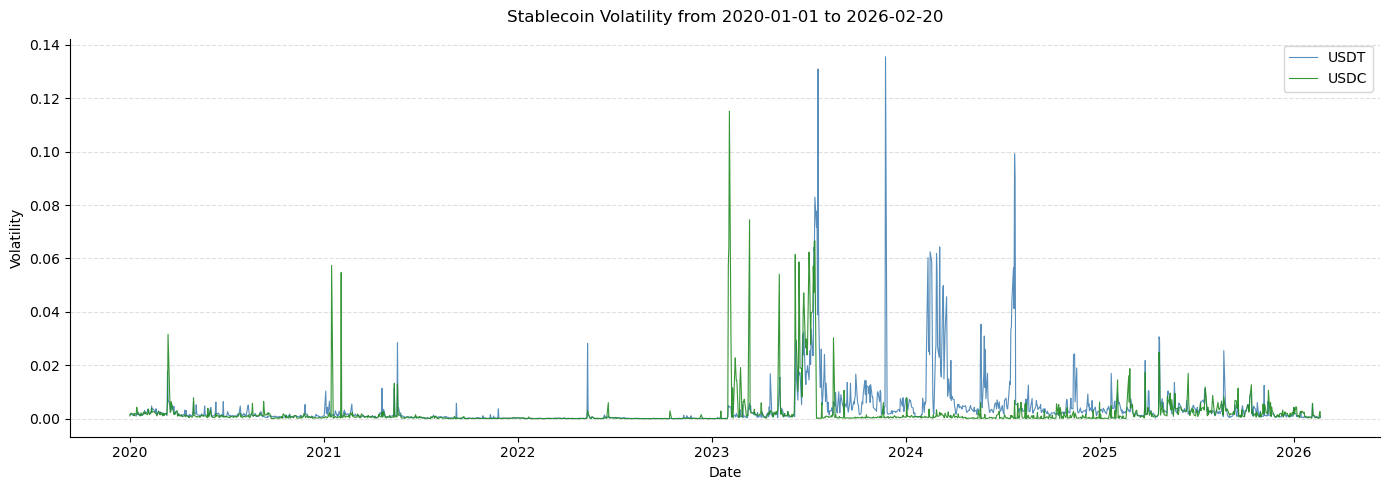

In [19]:
usdt_vol = parkinson_vol(df_volatility['USDT_USD_High'], df_volatility['USDT_USD_Low'])
usdc_vol = parkinson_vol(df_volatility['USDC_USD_High'], df_volatility['USDC_USD_Low'])
dates    = df_volatility['Date']

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dates, usdt_vol, color='steelblue',   linewidth=0.8, label='USDT', alpha=0.9)
ax.plot(dates, usdc_vol, color='forestgreen', linewidth=0.8, label='USDC', alpha=0.9)

start = dates.min().strftime('%Y-%m-%d')
end   = dates.max().strftime('%Y-%m-%d')
ax.set_title(f'Stablecoin Volatility from {start} to {end}', fontsize=12, pad=12)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Volatility', fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(frameon=True, fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('stablecoin_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
usdt_vol = parkinson_vol(df_volatility['USDT_USD_High'], df_volatility['USDT_USD_Low'])
usdc_vol = parkinson_vol(df_volatility['USDC_USD_High'], df_volatility['USDC_USD_Low'])

threshold = 0.15
print("=== USDT suspicious rows ===")
mask = usdt_vol > threshold
print(df_volatility[mask][['Date', 'USDT_USD_High', 'USDT_USD_Low']].to_string())

print("\n=== USDC suspicious rows ===")
mask = usdc_vol > threshold
print(df_volatility[mask][['Date', 'USDC_USD_High', 'USDC_USD_Low']].to_string())

=== USDT suspicious rows ===
Empty DataFrame
Columns: [Date, USDT_USD_High, USDT_USD_Low]
Index: []

=== USDC suspicious rows ===
Empty DataFrame
Columns: [Date, USDC_USD_High, USDC_USD_Low]
Index: []


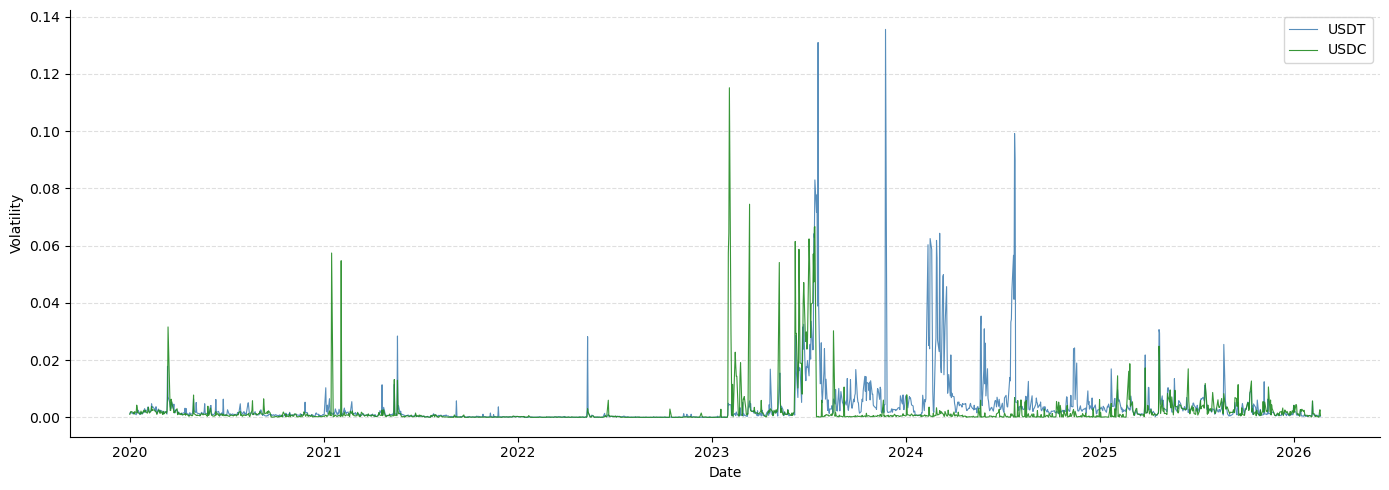

In [24]:
usdt_vol = parkinson_vol(df_volatility['USDT_USD_High'], df_volatility['USDT_USD_Low'])
usdc_vol = parkinson_vol(df_volatility['USDC_USD_High'], df_volatility['USDC_USD_Low'])
dates    = df_volatility['Date']

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dates, usdt_vol, color='steelblue',   linewidth=0.8, label='USDT', alpha=0.9)
ax.plot(dates, usdc_vol, color='forestgreen', linewidth=0.8, label='USDC', alpha=0.9)

start = dates.min().strftime('%Y-%m-%d')
end   = dates.max().strftime('%Y-%m-%d')
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Volatility', fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(frameon=True, fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('stablecoin_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation and Regression
$$
Pearson Correlation = \rho_{x,y} = \frac{cov(x,y)}{\sigma_x \sigma_y}
$$

In [25]:
def parkinson_vol(high, low):
    return np.sqrt((np.log(high) - np.log(low))**2 / (4 * np.log(2)))

vol_df = pd.DataFrame({
    "Date":         df_volatility["Date"],
    "USDT_Vol":     parkinson_vol(df_volatility["USDT_USD_High"], df_volatility["USDT_USD_Low"]),
    "USDC_Vol":     parkinson_vol(df_volatility["USDC_USD_High"], df_volatility["USDC_USD_Low"]),
    "BTC_Vol":      parkinson_vol(df_volatility["BTC_USD_High"],  df_volatility["BTC_USD_Low"]),
    "ETH_Vol":      parkinson_vol(df_volatility["ETH_USD_High"],  df_volatility["ETH_USD_Low"]),
    "DXY_Vol":      parkinson_vol(df_volatility["High _DXY"],     df_volatility["Low _DXY"]),
    "XAU_Vol":      parkinson_vol(df_volatility["High _XAU"],     df_volatility["Low _XAU"]),
    "SP500_Vol":    parkinson_vol(df_volatility["High _SP"],       df_volatility["Low _SP"]),
    "KBW_Vol":      parkinson_vol(df_volatility["High _KBW"],      df_volatility["Low _KBW"]),
    "VIX_Level":    (df_volatility["High _VIX"] + df_volatility["Low _VIX"]) / 2,
}).dropna().reset_index(drop=True)

stablecoins = ["USDT_Vol", "USDC_Vol"]
factors     = ["BTC_Vol", "ETH_Vol", "DXY_Vol", "XAU_Vol", "SP500_Vol", "KBW_Vol", "VIX_Level"]

def stars(p):
    if p < 0.01:  return "***"
    if p < 0.05:  return "**"
    if p < 0.10:  return "*"
    return ""

print("=" * 65)
print("  Table: Pearson Correlations with Stablecoin Volatility")
print("=" * 65)
print(f"{'Factor':<15} {'USDT_Vol':>18} {'USDC_Vol':>18}")
print("-" * 65)

for factor in factors:
    row_parts = [f"{factor:<15}"]
    for sc in stablecoins:
        r, p = stats.pearsonr(vol_df[sc], vol_df[factor])
        row_parts.append(f"{r:>10.4f}{stars(p):<3}(p={p:.3f})")
    print("  ".join(row_parts))

print("-" * 65)
print("  Significance: *** p<0.01  ** p<0.05  * p<0.10")

all_vars = stablecoins + factors
corr_matrix = vol_df[all_vars].corr(method="pearson").round(4)

print("\n\n" + "=" * 65)
print("  Full Pearson Correlation Matrix")
print("=" * 65)
print(corr_matrix.to_string())

X = vol_df[factors].copy()
X_const = pd.concat([pd.Series(1, index=X.index, name="const"), X], axis=1)

vif_data = pd.DataFrame({
    "Factor": factors,
    "VIF":    [variance_inflation_factor(X_const.values, i + 1) for i in range(len(factors))]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_data["Verdict"] = vif_data["VIF"].apply(
    lambda v: "🔴 Severe (>10)"    if v > 10
    else      "🟠 Moderate (5-10)" if v > 5
    else      "🟡 Mild (2.5-5)"    if v > 2.5
    else      "🟢 OK (<2.5)"
)

print("\n\n" + "=" * 55)
print("  VIF — Multicollinearity Check")
print("=" * 55)
print(f"{'Factor':<15} {'VIF':>10}   {'Verdict'}")
print("-" * 55)
for _, row in vif_data.iterrows():
    print(f"  {row['Factor']:<15} {row['VIF']:>8.2f}   {row['Verdict']}")
print("-" * 55)
print("  Rule of thumb: VIF > 10 = severe multicollinearity")
print("                 VIF > 5  = moderate, worth investigating")

X_scaled = (X - X.mean()) / X.std()
eigenvalues = np.linalg.eigvals(X_scaled.T @ X_scaled)
condition_number = np.sqrt(eigenvalues.max() / eigenvalues.min())

print("\n\n" + "=" * 55)
print("  Condition Number (Eigenvalue Decomposition)")
print("=" * 55)
print(f"  Condition Number : {condition_number:.2f}")
if condition_number < 30:
    verdict = "🟢 No serious multicollinearity"
elif condition_number < 100:
    verdict = "🟠 Moderate multicollinearity"
else:
    verdict = "🔴 Severe multicollinearity"
print(f"  Verdict          : {verdict}")
print(f"  (Thresholds: <30 = OK, 30–100 = moderate, >100 = severe)")

print("\n\n" + "=" * 55)
print("  High Correlation Pairs Among Factors (|r| > 0.70)")
print("=" * 55)
factor_corr = vol_df[factors].corr()
found = False
for i in range(len(factors)):
    for j in range(i + 1, len(factors)):
        r = factor_corr.iloc[i, j]
        if abs(r) > 0.70:
            print(f"  {factors[i]} <-> {factors[j]}: r = {r:.4f} ⚠️")
            found = True
if not found:
    print("  ✅ No factor pairs with |r| > 0.70")

  Table: Pearson Correlations with Stablecoin Volatility
Factor                    USDT_Vol           USDC_Vol
-----------------------------------------------------------------
BTC_Vol             -0.0002   (p=0.992)      0.0230   (p=0.357)
ETH_Vol             -0.0140   (p=0.574)      0.0199   (p=0.426)
DXY_Vol             -0.0550** (p=0.028)      0.0681***(p=0.006)
XAU_Vol             -0.0500** (p=0.045)      0.0290   (p=0.246)
SP500_Vol           -0.0990***(p=0.000)     -0.0028   (p=0.911)
KBW_Vol             -0.0547** (p=0.029)      0.0596** (p=0.017)
VIX_Level           -0.1960***(p=0.000)     -0.0562** (p=0.024)
-----------------------------------------------------------------
  Significance: *** p<0.01  ** p<0.05  * p<0.10


  Full Pearson Correlation Matrix
           USDT_Vol  USDC_Vol  BTC_Vol  ETH_Vol  DXY_Vol  XAU_Vol  SP500_Vol  KBW_Vol  VIX_Level
USDT_Vol     1.0000    0.2632  -0.0002  -0.0140  -0.0550  -0.0500    -0.0990  -0.0547    -0.1960
USDC_Vol     0.2632    1.0000  

We now use a linear regression model to examine the impact of these factors on stabelcoin volatility to identify potential drivers for the same using the following equation:

$$
V_{SC,t} = \beta_0 
+ \beta_1 V_{BTC,t} 
+ \beta_2 V_{ETH,t} 
+ \beta_3 V_{DXY,t} 
+ \beta_4 V_{S\&P500,t} 
+ \beta_5 V_{SC,t-1} 
+ \beta_6 V_{KBW,t} 
+ \beta_7 V_{XAU,t} 
+ \beta_8 L_{VIX,t}
+ \boldsymbol{\beta}_9^\top \mathbf{D}_{\text{year}}
+ \epsilon_t
$$

In [26]:
reg_df = vol_df.copy()

reg_df["USDT_Vol_lag1"] = reg_df["USDT_Vol"].shift(1)
reg_df["USDC_Vol_lag1"] = reg_df["USDC_Vol"].shift(1)

reg_df["Year"] = pd.to_datetime(reg_df["Date"]).dt.year
year_dummies = pd.get_dummies(reg_df["Year"], prefix="D", drop_first=True).astype(int)
reg_df = pd.concat([reg_df, year_dummies], axis=1).dropna().reset_index(drop=True)

dummy_cols = [c for c in reg_df.columns if c.startswith("D_")]

def run_regression(y_col, df):
    """
    OLS with Newey-West HAC standard errors.
    Both USDT_Vol_lag1 and USDC_Vol_lag1 are included in every regression:
      - own lag  captures autocorrelation / persistence
      - cross lag captures cross-stablecoin volatility spillover
    """
    X_cols = [
        "BTC_Vol", "ETH_Vol", "DXY_Vol", "SP500_Vol",
        "USDT_Vol_lag1",
        "USDC_Vol_lag1",
        "KBW_Vol", "XAU_Vol", "VIX_Level"
    ] + dummy_cols

    y = df[y_col]
    X = sm.add_constant(df[X_cols])
    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 10})
    return model

models = {
    "USDT": run_regression("USDT_Vol", reg_df),
    "USDC": run_regression("USDC_Vol", reg_df),
}

def stars(p):
    if p < 0.01:  return "***"
    if p < 0.05:  return "**"
    if p < 0.10:  return "*"
    return ""

var_labels = {
    "const":          "Intercept",
    "BTC_Vol":        "BTC Volatility",
    "ETH_Vol":        "ETH Volatility",
    "DXY_Vol":        "DXY Volatility",
    "SP500_Vol":      "S&P 500 Volatility",
    "USDT_Vol_lag1":  "USDT Vol (t-1)",
    "USDC_Vol_lag1":  "USDC Vol (t-1)",
    "KBW_Vol":        "KBW Volatility",
    "XAU_Vol":        "XAU Volatility",
    "VIX_Level":      "VIX (Level)",
}

base_vars = [
    "const", "BTC_Vol", "ETH_Vol", "DXY_Vol", "SP500_Vol",
    "USDT_Vol_lag1", "USDC_Vol_lag1",
    "KBW_Vol", "XAU_Vol", "VIX_Level"
]

print("=" * 75)
print("  Regression Results: Stablecoin Volatility")
print("  Standard errors: Newey-West HAC (maxlags=10)")
print("=" * 75)
print(f"  {'Variable':<25} {'USDT':>20} {'USDC':>20}")
print("-" * 75)

for var in base_vars:
    row = f"  {var_labels.get(var, var):<25}"
    for sc, model in models.items():
        if var in model.params:
            coef = model.params[var]
            pval = model.pvalues[var]
            se   = model.bse[var]
            row += f"  {coef:>8.4f}{stars(pval):<3} ({se:.6f})"
        else:
            row += f"  {'—':>20}"
    print(row)

print(f"\n  {'Year Dummies':<25} {'Yes':>20} {'Yes':>20}")
print("-" * 75)

print(f"\n  {'Observations':<25}", end="")
for sc, model in models.items():
    print(f"  {int(model.nobs):>20}", end="")

print(f"\n  {'R-squared':<25}", end="")
for sc, model in models.items():
    print(f"  {model.rsquared:>20.4f}", end="")

print(f"\n  {'Adj. R-squared':<25}", end="")
for sc, model in models.items():
    print(f"  {model.rsquared_adj:>20.4f}", end="")

print(f"\n  {'F-statistic':<25}", end="")
for sc, model in models.items():
    print(f"  {model.fvalue:>20.4f}", end="")

print(f"\n  {'F p-value':<25}", end="")
for sc, model in models.items():
    print(f"  {model.f_pvalue:>20.4f}", end="")

print(f"\n  {'Durbin-Watson':<25}", end="")
for sc, model in models.items():
    dw = durbin_watson(model.resid)
    print(f"  {dw:>20.4f}", end="")

print(f"\n  {'AIC':<25}", end="")
for sc, model in models.items():
    print(f"  {model.aic:>20.4f}", end="")

print(f"\n  {'BIC':<25}", end="")
for sc, model in models.items():
    print(f"  {model.bic:>20.4f}", end="")

print("\n" + "-" * 75)
print("  Significance: *** p<0.01  ** p<0.05  * p<0.10")
print("  Coefficients shown with HAC standard errors in parentheses")

print("\n\n" + "=" * 55)
print("  Breusch-Pagan Test for Heteroskedasticity")
print("=" * 55)
for sc, model in models.items():
    X_cols = [
        "BTC_Vol", "ETH_Vol", "DXY_Vol", "SP500_Vol",
        "USDT_Vol_lag1", "USDC_Vol_lag1",
        "KBW_Vol", "XAU_Vol", "VIX_Level"
    ] + dummy_cols
    X = sm.add_constant(reg_df[X_cols])
    bp_stat, bp_p, _, _ = het_breuschpagan(model.resid, X)
    verdict = "Heteroskedasticity present → HAC SEs justified ✅" if bp_p < 0.05 else "No heteroskedasticity detected"
    print(f"  {sc}: stat={bp_stat:.2f}, p={bp_p:.4f} — {verdict}")

  Regression Results: Stablecoin Volatility
  Standard errors: Newey-West HAC (maxlags=10)
  Variable                                  USDT                 USDC
---------------------------------------------------------------------------
  Intercept                    0.0011*   (0.000689)   -0.0003    (0.000519)
  BTC Volatility              -0.0035    (0.003230)   -0.0073    (0.005791)
  ETH Volatility               0.0318*** (0.007212)    0.0291*** (0.005853)
  DXY Volatility               0.0740    (0.112326)    0.2059*   (0.120845)
  S&P 500 Volatility          -0.0474    (0.038830)   -0.0495    (0.063915)
  USDT Vol (t-1)               0.5700*** (0.098743)    0.0170    (0.025029)
  USDC Vol (t-1)               0.1359*   (0.071966)    0.5782*** (0.090957)
  KBW Volatility               0.0414    (0.026046)    0.0721    (0.058391)
  XAU Volatility              -0.0297    (0.023444)    0.0115    (0.026958)
  VIX (Level)                 -0.0001**  (0.000034)   -0.0001    (0.000040)

  

Volatility Connectedness among stablecoins and external factors

In [27]:
spillover_vars = {
    "USDT":  vol_df["USDT_Vol"],
    "USDC":  vol_df["USDC_Vol"],
    "BTC":   vol_df["BTC_Vol"],
    "ETH":   vol_df["ETH_Vol"],
    "DXY":   vol_df["DXY_Vol"],
    "XAU":   vol_df["XAU_Vol"],
    "S&P500":vol_df["SP500_Vol"],
    "KBW":   vol_df["KBW_Vol"],
}

data = pd.DataFrame(spillover_vars).dropna()
N    = data.shape[1]
H    = 10

model    = VAR(data)
lag_sel  = model.select_order(maxlags=10)
p        = lag_sel.bic
print(f"BIC-selected lag length: p = {p}")
results  = model.fit(p)

irf    = results.irf(H)
A      = irf.irfs
Sigma  = results.sigma_u

def compute_gfevd(A, Sigma, H):
    """
    Compute normalized GFEVD following Pesaran & Shin (1998).
    Returns N×N matrix where entry [i,j] = % of i's forecast variance due to shock in j.
    """
    N = Sigma.shape[0]
    sigma_diag = np.sqrt(np.diag(Sigma))

    numerator   = np.zeros((N, N))
    denominator = np.zeros(N)

    for h in range(H):
        Ah = A[h]
        AhS = Ah @ Sigma

        for i in range(N):
            ei = np.zeros(N); ei[i] = 1
            denominator[i] += float(ei @ AhS @ Ah.T @ ei)

            for j in range(N):
                ej = np.zeros(N); ej[j] = 1
                num_ij = float(ei @ AhS @ ej) ** 2 / (sigma_diag[j] ** 2)
                numerator[i, j] += num_ij

    raw = numerator / denominator[:, None]

    gfevd_norm = raw / raw.sum(axis=1, keepdims=True)

    return gfevd_norm * 100

gfevd = compute_gfevd(A, Sigma, H)

labels = list(spillover_vars.keys())

spillover_df = pd.DataFrame(gfevd, index=labels, columns=labels).round(2)

spillover_df["FROM others"] = (spillover_df.sum(axis=1) - np.diag(gfevd)).round(2)

to_others = (spillover_df[labels].sum(axis=0) - np.diag(gfevd)).round(2)
to_others["FROM others"] = np.nan

net = (to_others[labels] - spillover_df["FROM others"]).round(2)
net["FROM others"] = np.nan

tsi = spillover_df["FROM others"].sum() / (N * 100) * 100

to_row  = to_others.copy(); to_row.name  = "TO others"
net_row = net.copy();        net_row.name = "NET spillovers"

table = pd.concat([spillover_df, to_row.to_frame().T, net_row.to_frame().T])

pd.set_option("display.float_format", lambda x: f"{x:.2f}" if not np.isnan(x) else "—")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("\n")
print("Table 2.4. The static volatility spillovers.")
print("=" * 110)
print(table.to_string(na_rep="—"))
print("=" * 110)
print(f"Total Spillover Index (TSI) = {tsi:.2f}%")
print(f"\nNote: Based on GFEVD from VAR(p={p}), H={H}-step ahead forecasts.")
print("      BIC-selected lag length. Values are percentages.")
print("      Rows = FROM (received), Columns = TO (transmitted).")
print("      Diagonal = own-variance shares.")

BIC-selected lag length: p = 2


Table 2.4. The static volatility spillovers.
                USDT  USDC   BTC   ETH    DXY   XAU  S&P500   KBW  FROM others
USDT           88.10  9.33  0.22  0.97   0.26  0.23    0.82  0.08        11.91
USDC            1.78 94.43  0.13  1.11   1.00  0.44    0.13  0.97         5.56
BTC             0.24  0.22 67.65 28.33   0.22  0.50    1.60  1.25        32.36
ETH             0.97  0.98 21.47 65.97   1.08  2.04    5.26  2.23        34.03
DXY             0.18  0.38  0.22  1.31  67.40  6.63   15.90  7.98        32.60
XAU             0.02  0.24  0.69  3.20   6.94 74.99    7.14  6.78        25.01
S&P500          0.06  0.10  1.26  4.19   5.69  3.55   57.80 27.35        42.20
KBW             0.02  0.33  1.16  3.15   3.21  4.10   31.12 56.93        43.09
TO others       3.27 11.58 25.15 42.26  18.40 17.49   61.97 46.64            —
NET spillovers -8.64  6.02 -7.21  8.23 -14.20 -7.52   19.77  3.55            —
Total Spillover Index (TSI) = 28.34%

Note: Based on 

In [28]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


spillover_vars = {
    "USDT":   vol_df["USDT_Vol"],
    "USDC":   vol_df["USDC_Vol"],
    "BTC":    vol_df["BTC_Vol"],
    "ETH":    vol_df["ETH_Vol"],
    "DXY":    vol_df["DXY_Vol"],
    "XAU":    vol_df["XAU_Vol"],
    "S&P500": vol_df["SP500_Vol"],
    "KBW":    vol_df["KBW_Vol"],
}

data   = pd.DataFrame(spillover_vars).dropna().values
labels = list(spillover_vars.keys())
T, N   = data.shape
p      = 1
H      = 10

lam = 0.99
kap = 0.96


k    = N * p + 1
k_t  = N * k

def build_Z(X_lags):
    """Build regressor vector Z_t = I_N ⊗ [1, x_{t-1}',...,x_{t-p}']"""
    z = np.concatenate([[1], X_lags.flatten()])
    return np.kron(np.eye(N), z)

init_obs = max(int(0.10 * T), N * p + 5)

Y_init = data[p:init_obs]
X_init = np.hstack([np.ones((init_obs - p, 1)),
                    data[p-1:init_obs-1]] if p == 1 else
                   [np.ones((init_obs - p, 1))] +
                   [data[p-i-1:init_obs-i-1] for i in range(p)])

beta_ols = np.linalg.lstsq(X_init, Y_init, rcond=None)[0]
beta_t   = beta_ols.T.flatten()

P_t = np.eye(k_t) * 10

resid_init = Y_init - X_init @ beta_ols
Sigma_t    = (resid_init.T @ resid_init) / (init_obs - p - k)
Sigma_t    = (Sigma_t + Sigma_t.T) / 2

print(f"TVP-VAR setup: N={N}, T={T}, p={p}, H={H}")
print(f"Forgetting factors: λ={lam}, κ={kap}")
print(f"Initialisation observations: {init_obs}")
print("Running Kalman filter...")

beta_store  = np.zeros((T, k_t))
Sigma_store = np.zeros((T, N, N))

for t in range(p, T):
    lags = data[t-p:t][::-1]
    Z_t  = build_Z(lags)

    beta_pred = beta_t
    P_pred    = P_t / lam

    x_t      = data[t]
    eps_t    = x_t - Z_t @ beta_pred
    Sigma_t  = kap * Sigma_t + (1 - kap) * np.outer(eps_t, eps_t)
    Sigma_t  = (Sigma_t + Sigma_t.T) / 2

    S_t = Z_t @ P_pred @ Z_t.T + Sigma_t
    S_t = (S_t + S_t.T) / 2
    K_t = P_pred @ Z_t.T @ np.linalg.inv(S_t)

    beta_t = beta_pred + K_t @ eps_t
    P_t    = (np.eye(k_t) - K_t @ Z_t) @ P_pred

    beta_store[t]  = beta_t
    Sigma_store[t] = Sigma_t

print("Kalman filter complete. Computing GFEVD...")

def get_companion(beta_t, N, p):
    """Extract N x N VAR coefficient matrices from beta_t and return companion."""
    k = N * p + 1
    B = beta_t.reshape(N, k)
    coef_cols = B[:, 1:]

    if p == 1:
        return coef_cols
    else:
        Phi = np.zeros((N * p, N * p))
        Phi[:N, :] = coef_cols
        Phi[N:, :-N] = np.eye(N * (p - 1))
        return Phi

def compute_gfevd_t(beta_t, Sigma_t, N, p, H):
    """Compute GFEVD for a single time point."""
    Phi = get_companion(beta_t, N, p)

    A = [np.eye(N)]
    for h in range(1, H):
        if p == 1:
            A.append(A[-1] @ Phi)
        else:
            Ah = np.zeros((N, N))
            for j in range(min(h, p)):
                B = beta_t.reshape(N, N * p + 1)[:, 1 + j*N:1 + (j+1)*N]
                Ah += A[h - 1 - j] @ B if (h - 1 - j) >= 0 else np.zeros((N, N))
            A.append(Ah)

    sigma_diag = np.sqrt(np.maximum(np.diag(Sigma_t), 1e-12))

    num   = np.zeros((N, N))
    denom = np.zeros(N)

    for h in range(H):
        Ah  = A[h]
        AhS = Ah @ Sigma_t
        for i in range(N):
            ei = np.zeros(N); ei[i] = 1
            denom[i] += float(ei @ AhS @ Ah.T @ ei)
            for j in range(N):
                ej = np.zeros(N); ej[j] = 1
                num[i, j] += float(ei @ AhS @ ej) ** 2 / (sigma_diag[j] ** 2)

    denom = np.maximum(denom, 1e-12)
    raw   = num / denom[:, None]
    norm  = raw / np.maximum(raw.sum(axis=1, keepdims=True), 1e-12)
    return norm * 100

burn_in   = init_obs + 20
gfevd_sum = np.zeros((N, N))
count     = 0

for t in range(burn_in, T):
    try:
        g = compute_gfevd_t(beta_store[t], Sigma_store[t], N, p, H)
        if not np.any(np.isnan(g)) and not np.any(np.isinf(g)):
            gfevd_sum += g
            count     += 1
    except Exception:
        continue

gfevd_avg = gfevd_sum / count
print(f"GFEVD averaged over {count} time points.")

spillover_df = pd.DataFrame(gfevd_avg, index=labels, columns=labels).round(2)

spillover_df["FROM others"] = (
    spillover_df.sum(axis=1) - np.diag(gfevd_avg)
).round(2)

to_others = (spillover_df[labels].sum(axis=0) - np.diag(gfevd_avg)).round(2)
net        = (to_others - spillover_df["FROM others"]).round(2)

to_row       = to_others.copy(); to_row["FROM others"]  = float("nan")
net_row      = net.copy();       net_row["FROM others"] = float("nan")
to_row.name  = "TO others"
net_row.name = "NET spillovers"

table = pd.concat([spillover_df,
                   to_row.to_frame().T,
                   net_row.to_frame().T])

tsi = spillover_df["FROM others"].sum() / (N * 100) * 100

pd.set_option("display.float_format", lambda x: f"{x:.2f}" if pd.notna(x) else "—")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("\n\nTable 2.4. The static volatility spillovers (TVP-VAR).")
print("=" * 110)
print(table.to_string(na_rep="—"))
print("=" * 110)
print(f"Total Spillover Index (TSI) = {tsi:.2f}%")
print(f"\nNote: TVP-VAR with forgetting factors (λ={lam}, κ={kap}).")
print(f"      GFEVD averaged over {count} observations, H={H}-step ahead, p={p} lag (BIC).")
print("      Rows = FROM (received), Columns = TO (transmitted).")

TVP-VAR setup: N=8, T=1603, p=1, H=10
Forgetting factors: λ=0.99, κ=0.96
Initialisation observations: 160
Running Kalman filter...
Kalman filter complete. Computing GFEVD...
GFEVD averaged over 1423 time points.


Table 2.4. The static volatility spillovers (TVP-VAR).
                USDT  USDC   BTC   ETH   DXY   XAU  S&P500   KBW  FROM others
USDT           70.40  9.59  5.10  6.76  2.61  1.97    2.02  1.54        29.59
USDC           12.17 71.36  3.17  5.17  2.00  2.65    1.91  1.57        28.64
BTC             4.59  2.19 52.48 28.69  2.04  3.88    3.76  2.38        47.53
ETH             5.88  4.15 27.08 48.89  2.66  4.08    4.40  2.87        51.12
DXY             2.80  2.08  2.71  3.60 62.34 12.08    8.21  6.16        37.64
XAU             3.43  3.64  3.99  4.69 11.58 59.88    6.23  6.56        40.12
S&P500          2.54  3.33  3.73  4.71  6.22  4.61   56.18 18.68        43.82
KBW             1.68  1.49  2.99  3.50  5.36  5.26   22.38 57.34        42.66
TO others      33.09 26.47 48

In [29]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


spillover_vars = {
    "USDT":   vol_df["USDT_Vol"],
    "USDC":   vol_df["USDC_Vol"],
    "BTC":    vol_df["BTC_Vol"],
    "ETH":    vol_df["ETH_Vol"],
    "DXY":    vol_df["DXY_Vol"],
    "XAU":    vol_df["XAU_Vol"],
    "S&P500": vol_df["SP500_Vol"],
    "KBW":    vol_df["KBW_Vol"],
}

data   = pd.DataFrame(spillover_vars).dropna().values
labels = list(spillover_vars.keys())
T, N   = data.shape
p      = 2
H      = 10

lam = 0.99
kap = 0.96


k    = N * p + 1
k_t  = N * k

def build_Z(X_lags):
    """Build regressor vector Z_t = I_N ⊗ [1, x_{t-1}',...,x_{t-p}']"""
    z = np.concatenate([[1], X_lags.flatten()])
    return np.kron(np.eye(N), z)

init_obs = max(int(0.10 * T), N * p + 5)

Y_init = data[p:init_obs]
X_init = np.hstack([np.ones((init_obs - p, 1)),
                    data[p-1:init_obs-1]] if p == 1 else
                   [np.ones((init_obs - p, 1))] +
                   [data[p-i-1:init_obs-i-1] for i in range(p)])

beta_ols = np.linalg.lstsq(X_init, Y_init, rcond=None)[0]
beta_t   = beta_ols.T.flatten()

P_t = np.eye(k_t) * 10

resid_init = Y_init - X_init @ beta_ols
Sigma_t    = (resid_init.T @ resid_init) / (init_obs - p - k)
Sigma_t    = (Sigma_t + Sigma_t.T) / 2

print(f"TVP-VAR setup: N={N}, T={T}, p={p}, H={H}")
print(f"Forgetting factors: λ={lam}, κ={kap}")
print(f"Initialisation observations: {init_obs}")
print("Running Kalman filter...")

beta_store  = np.zeros((T, k_t))
Sigma_store = np.zeros((T, N, N))

for t in range(p, T):
    lags = data[t-p:t][::-1]
    Z_t  = build_Z(lags)

    beta_pred = beta_t
    P_pred    = P_t / lam

    x_t      = data[t]
    eps_t    = x_t - Z_t @ beta_pred
    Sigma_t  = kap * Sigma_t + (1 - kap) * np.outer(eps_t, eps_t)
    Sigma_t  = (Sigma_t + Sigma_t.T) / 2

    S_t = Z_t @ P_pred @ Z_t.T + Sigma_t
    S_t = (S_t + S_t.T) / 2
    K_t = P_pred @ Z_t.T @ np.linalg.inv(S_t)

    beta_t = beta_pred + K_t @ eps_t
    P_t    = (np.eye(k_t) - K_t @ Z_t) @ P_pred

    beta_store[t]  = beta_t
    Sigma_store[t] = Sigma_t

print("Kalman filter complete. Computing GFEVD...")

def get_companion(beta_t, N, p):
    """Extract N x N VAR coefficient matrices from beta_t and return companion."""
    k = N * p + 1
    B = beta_t.reshape(N, k)
    coef_cols = B[:, 1:]

    if p == 1:
        return coef_cols
    else:
        Phi = np.zeros((N * p, N * p))
        Phi[:N, :] = coef_cols
        Phi[N:, :-N] = np.eye(N * (p - 1))
        return Phi

def compute_gfevd_t(beta_t, Sigma_t, N, p, H):
    """Compute GFEVD for a single time point."""
    Phi = get_companion(beta_t, N, p)

    A = [np.eye(N)]
    for h in range(1, H):
        if p == 1:
            A.append(A[-1] @ Phi)
        else:
            Ah = np.zeros((N, N))
            for j in range(min(h, p)):
                B = beta_t.reshape(N, N * p + 1)[:, 1 + j*N:1 + (j+1)*N]
                Ah += A[h - 1 - j] @ B if (h - 1 - j) >= 0 else np.zeros((N, N))
            A.append(Ah)

    sigma_diag = np.sqrt(np.maximum(np.diag(Sigma_t), 1e-12))

    num   = np.zeros((N, N))
    denom = np.zeros(N)

    for h in range(H):
        Ah  = A[h]
        AhS = Ah @ Sigma_t
        for i in range(N):
            ei = np.zeros(N); ei[i] = 1
            denom[i] += float(ei @ AhS @ Ah.T @ ei)
            for j in range(N):
                ej = np.zeros(N); ej[j] = 1
                num[i, j] += float(ei @ AhS @ ej) ** 2 / (sigma_diag[j] ** 2)

    denom = np.maximum(denom, 1e-12)
    raw   = num / denom[:, None]
    norm  = raw / np.maximum(raw.sum(axis=1, keepdims=True), 1e-12)
    return norm * 100

burn_in   = init_obs + 20
gfevd_sum = np.zeros((N, N))
count     = 0

for t in range(burn_in, T):
    try:
        g = compute_gfevd_t(beta_store[t], Sigma_store[t], N, p, H)
        if not np.any(np.isnan(g)) and not np.any(np.isinf(g)):
            gfevd_sum += g
            count     += 1
    except Exception:
        continue

gfevd_avg = gfevd_sum / count
print(f"GFEVD averaged over {count} time points.")

spillover_df = pd.DataFrame(gfevd_avg, index=labels, columns=labels).round(2)

spillover_df["FROM others"] = (
    spillover_df.sum(axis=1) - np.diag(gfevd_avg)
).round(2)

to_others = (spillover_df[labels].sum(axis=0) - np.diag(gfevd_avg)).round(2)
net        = (to_others - spillover_df["FROM others"]).round(2)

to_row       = to_others.copy(); to_row["FROM others"]  = float("nan")
net_row      = net.copy();       net_row["FROM others"] = float("nan")
to_row.name  = "TO others"
net_row.name = "NET spillovers"

table = pd.concat([spillover_df,
                   to_row.to_frame().T,
                   net_row.to_frame().T])

tsi = spillover_df["FROM others"].sum() / (N * 100) * 100

pd.set_option("display.float_format", lambda x: f"{x:.2f}" if pd.notna(x) else "—")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("\n\nTable 2.4. The static volatility spillovers (TVP-VAR).")
print("=" * 110)
print(table.to_string(na_rep="—"))
print("=" * 110)
print(f"Total Spillover Index (TSI) = {tsi:.2f}%")
print(f"\nNote: TVP-VAR with forgetting factors (λ={lam}, κ={kap}).")
print(f"      GFEVD averaged over {count} observations, H={H}-step ahead, p={p} lag (BIC).")
print("      Rows = FROM (received), Columns = TO (transmitted).")

TVP-VAR setup: N=8, T=1603, p=2, H=10
Forgetting factors: λ=0.99, κ=0.96
Initialisation observations: 160
Running Kalman filter...
Kalman filter complete. Computing GFEVD...
GFEVD averaged over 1423 time points.


Table 2.4. The static volatility spillovers (TVP-VAR).
                USDT  USDC   BTC   ETH   DXY   XAU  S&P500   KBW  FROM others
USDT           68.63 11.62  4.68  6.80  2.24  1.90    2.40  1.73        31.37
USDC           13.34 69.50  3.35  5.09  1.72  2.23    2.66  2.12        30.51
BTC             4.62  3.04 52.38 26.85  2.51  4.22    3.70  2.68        47.62
ETH             6.76  5.61 24.46 47.78  2.99  4.15    4.80  3.46        52.23
DXY             2.61  1.98  2.83  3.72 62.11 12.20    8.21  6.33        37.88
XAU             3.74  3.04  4.00  4.73 11.39 59.62    6.95  6.52        40.37
S&P500          3.01  4.66  3.70  4.49  5.99  4.93   54.90 18.32        45.10
KBW             3.54  2.49  3.26  3.75  5.84  5.44   22.02 53.66        46.34
TO others      37.62 32.44 46